# Day 29: 跟随 Auquan/Tutorials 仓库（Day 1/3）

**日期**: 2026-08-01 | **阶段**: 实战整合 | **时长**: 5小时

## 今日目标
- 克隆 Auquan/Tutorials 仓库，了解项目结构
- 逐个阅读 Notebook，理解每个的目的和方法
- 记录：哪些已经会？哪些是新的？列出学习清单

## Auquan 仓库全景（21个Notebook）

| 分类 | Notebook | 核心内容 | 掌握度 |
|------|----------|---------|:--:|
| 数学 | Random Variables | 随机变量/正态分布 | ✅ |
| 数学 | Expected Value and Std Dev | 期望值/标准差/夏普 | ✅ |
| 数学 | Covariance, Correlation | 协方差/相关系数/置信区间 | ✅ |
| 数学 | Integration, Cointegration | 平稳性/ADF检验/协整 | 🆕 |
| 策略 | Mean Reversion | 均值回归/布林带 | ✅ |
| 策略 | Momentum Strategies | 动量策略/趋势跟踪 | ✅ |
| 策略 | Measuring Momentum | 均线带/物理动量指标 | 🆕 |
| 策略 | Pairs Trading | 配对交易/价差 | 🆕 |
| 策略 | Long-Short Strategies | 排名多空 | 🆕 |
| 策略 | Overfitting | 过拟合/多项式演示 | 🆕⚠️ |
| 策略 | Model Selection Pitfalls | 遗漏变量/伪回归 | 🆕⚠️ |
| 时序 | Time Series 1-4 | 平稳性/ACF/ARMA/ARIMA/GARCH | 🆕 |
| 时序 | ARIMA+GARCH SPX | SPX实战建模 | 🆕 |
| ML | Introduction to ML | ML交易6步框架 | 🆕 |
| ML | Simple ML Strategies | 特征工程/多模型/集成 | 🆕 |
| ML | Content Capturing | NLP文本特征 | 🆕🔮 |
| ML | Topic Modelling 10K | LDA主题模型 | 🆕🔮 |
| 其他 | momentum_backtest | 动量回测对比 | 🆕 |

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

import akshare as ak
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import pearsonr

# ====== 数据获取（stock_zh_a_daily 走新浪，比东方财富稳定）======
def safe_fetch(symbol, start='20240101', end='20250801'):
    """获取A股日线，自动识沪市/深市，统一列名"""
    code = symbol.zfill(6)
    prefix = 'sh' if code.startswith(('6','9')) else 'sz'
    full = f'{prefix}{code}'
    df = ak.stock_zh_a_daily(symbol=full, adjust='qfq')
    # 统一列名为中文，兼容 notebook 其余代码
    df = df.rename(columns={
        'date':'日期','open':'开盘','close':'收盘','high':'最高','low':'最低',
        'volume':'成交量','amount':'成交额','outstanding_share':'流通市值','turnover':'换手率'
    })
    df['日期'] = pd.to_datetime(df['日期'])
    df = df[(df['日期'] >= start) & (df['日期'] <= end)]
    print(f'✅ {symbol} 获取成功: {len(df)} 条')
    return df

print('✅ 环境就绪，safe_fetch 已定义')

✅ 环境就绪，safe_fetch 已定义


---
## 第一部分：数学基础（4个Notebook）

### 1.1-1.3 随机变量 / 期望值与标准差 / 协方差与相关性
这三个已经掌握。下面用招商银行做实盘演示。

✅ 600036 获取成功: 383 条
招商银行(600036) 日收益率统计
均值(期望):  0.001617 (0.1617%)
标准差:      0.014417 (1.4417%)
年化收益率:   40.42%
年化波动率:   22.80%
夏普比率:     1.77
偏度:         0.053 (负=左偏/暴跌多)
峰度:         4.124 (>0=肥尾)


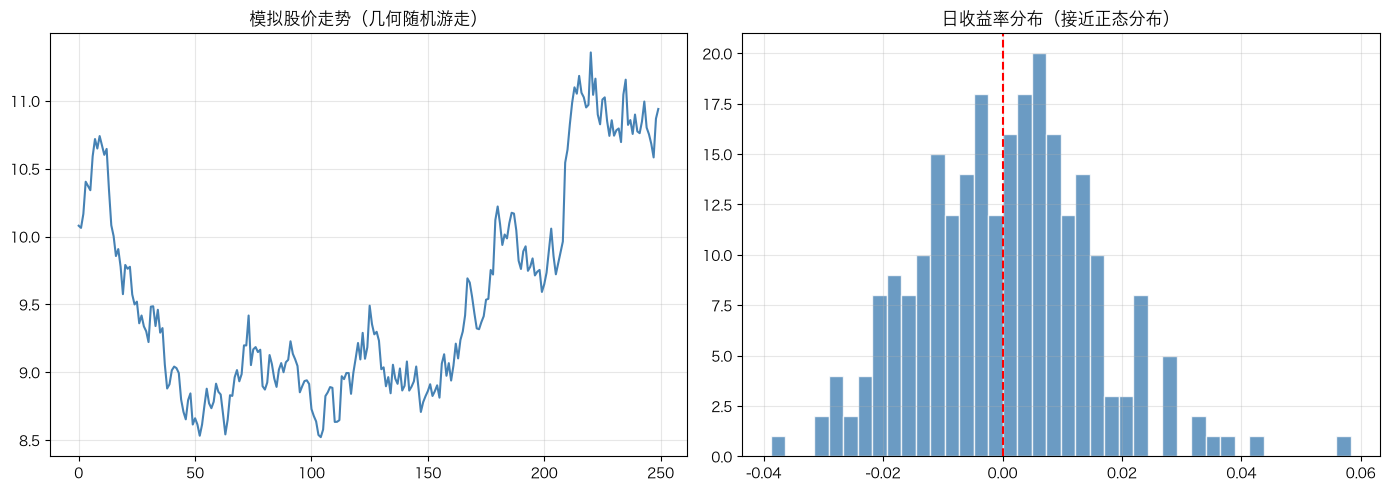

✅ 已掌握：随机变量/正态分布/期望值/标准差/夏普比率


In [9]:
# 获取招商银行数据（带自动重试）
df = safe_fetch('600036')
r = df['收盘'].pct_change().dropna()

print('='*50)
print('招商银行(600036) 日收益率统计')
print('='*50)
print(f'均值(期望):  {r.mean():.6f} ({r.mean()*100:.4f}%)')
print(f'标准差:      {r.std():.6f} ({r.std()*100:.4f}%)')
print(f'年化收益率:   {r.mean()*250*100:.2f}%')
print(f'年化波动率:   {r.std()*np.sqrt(250)*100:.2f}%')
print(f'夏普比率:     {r.mean()/r.std()*np.sqrt(250):.2f}')
print(f'偏度:         {r.skew():.3f} (负=左偏/暴跌多)')
print(f'峰度:         {r.kurtosis():.3f} (>0=肥尾)')

# 随机变量演示：模拟股价
np.random.seed(42)
daily_returns = np.random.normal(0.0005, 0.015, 250)
price = 10 * (1 + daily_returns).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(price, color='steelblue')
axes[0].set_title('模拟股价走势（几何随机游走）')
axes[0].grid(True, alpha=0.3)
axes[1].hist(daily_returns, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('日收益率分布（接近正态分布）')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/01_随机变量.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 已掌握：随机变量/正态分布/期望值/标准差/夏普比率')

✅ 600036 获取成功: 383 条
✅ 300750 获取成功: 383 条
✅ 600519 获取成功: 383 条
✅ 002594 获取成功: 383 条
✅ 601318 获取成功: 383 条


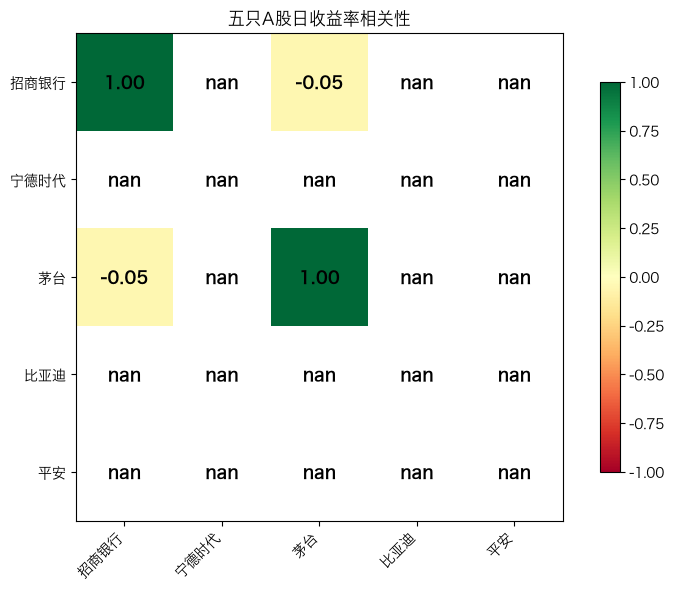

✅ 已掌握：协方差矩阵/相关系数热力图


In [11]:
# 五只A股相关性分析
stocks_dict = {'招商银行':'600036','宁德时代':'300750','茅台':'600519','比亚迪':'002594','平安':'601318'}
returns_df = pd.DataFrame()

for name, code in stocks_dict.items():
    d = safe_fetch(code)
    returns_df[name] = d['收盘'].pct_change()

corr = returns_df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_title('五只A股日收益率相关性')
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/02_相关性热力图.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 已掌握：协方差矩阵/相关系数热力图')

### 1.4 平稳性与协整 —— 🆕 新概念！

**核心理解**：
- 平稳 = 统计性质（均值/方差）不随时间变化
- 股价 → 非平稳（有趋势，ADF不能拒绝单位根）
- 收益率 → 平稳（围绕零轴波动）
- 协整 → 两个非平稳序列的线性组合是平稳的 → 配对交易的基础

In [12]:
print('🆕 核心新概念：平稳性 (Stationarity)')
print('-'*50)

price_series = df['收盘'].dropna()
ret_series = price_series.pct_change().dropna()

def adf_test(series, name):
    r = adfuller(series.dropna(), autolag='AIC')
    print(f'{name}: ADF={r[0]:.4f}, p={r[1]:.4f} → {"✅ 平稳" if r[1]<0.05 else "❌ 非平稳"}')

adf_test(price_series, '收盘价')
adf_test(ret_series, '日收益率')
print()
print('📝 关键理解：价格→非平稳(需差分), 收益率→平稳(可直接建模)')
print('📝 ARIMA(p,d,q)中的d就是差分次数，通常d=1（一阶差分）')

🆕 核心新概念：平稳性 (Stationarity)
--------------------------------------------------
收盘价: ADF=-1.1340, p=0.7013 → ❌ 非平稳
日收益率: ADF=-8.2695, p=0.0000 → ✅ 平稳

📝 关键理解：价格→非平稳(需差分), 收益率→平稳(可直接建模)
📝 ARIMA(p,d,q)中的d就是差分次数，通常d=1（一阶差分）


---
## 第二部分：交易策略（7个Notebook）

### 2.1 Mean Reversion（均值回归）—— ✅ 已会

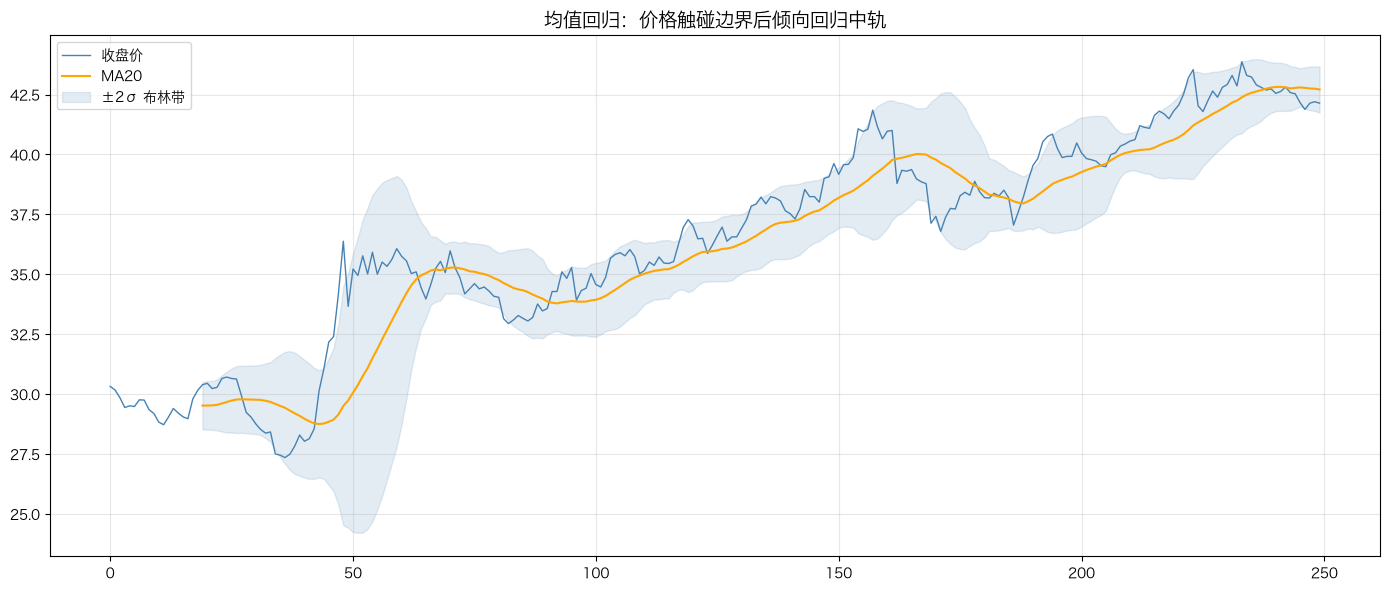

✅ 布林带 = 均值回归策略的实现


In [14]:
px = df['收盘'].iloc[-250:].values
window = 20
sma = pd.Series(px).rolling(window).mean()
std = pd.Series(px).rolling(window).std()
upper, lower = sma + 2*std, sma - 2*std

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(px, color='steelblue', linewidth=1, label='收盘价')
ax.plot(sma, color='orange', linewidth=1.5, label=f'MA{window}')
ax.fill_between(range(len(px)), lower, upper, alpha=0.15, color='steelblue', label='±2σ 布林带')
ax.set_title('均值回归：价格触碰边界后倾向回归中轨', fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/03_均值回归.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 布林带 = 均值回归策略的实现')

### 2.2 Momentum Strategies（动量策略）—— ✅ 已会

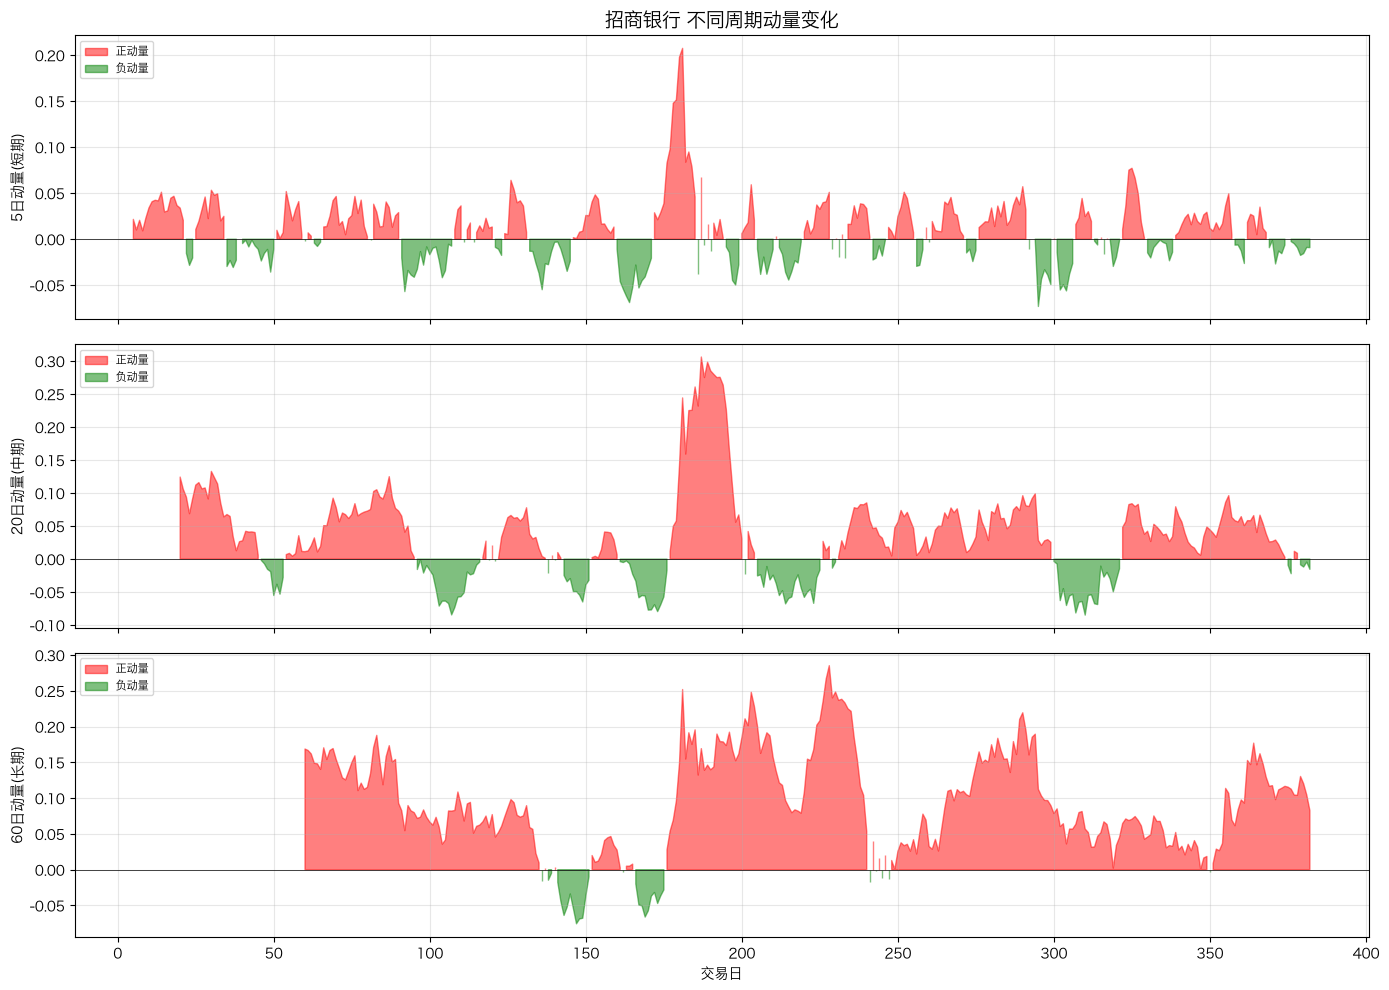

✅ 均线金叉/死叉 = 动量策略的实现
📝 短期动量噪音大，长期动量趋势更稳定


In [16]:
df['ret_5d'] = df['收盘'].pct_change(5)
df['ret_20d'] = df['收盘'].pct_change(20)
df['ret_60d'] = df['收盘'].pct_change(60)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, (col, title) in enumerate([('ret_5d','5日动量(短期)'), ('ret_20d','20日动量(中期)'), ('ret_60d','60日动量(长期)')]):
    axes[i].fill_between(range(len(df)), df[col], 0, where=df[col]>=0, color='red', alpha=0.5, label='正动量')
    axes[i].fill_between(range(len(df)), df[col], 0, where=df[col]<0, color='green', alpha=0.5, label='负动量')
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].set_ylabel(title); axes[i].legend(loc='upper left', fontsize=8); axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('交易日')
axes[0].set_title('招商银行 不同周期动量变化', fontsize=14)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/04_动量分析.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 均线金叉/死叉 = 动量策略的实现')
print('📝 短期动量噪音大，长期动量趋势更稳定')

### 2.3 Measuring Momentum —— 🆕 均线带/物理动量

🆕 Auquan独创：测量动量的三种方法
--------------------------------------------------
方法1：均线交叉带 (MA Ribbon)
  - 画10条不同周期的均线(10~100天)
  - 均线排列向上 → 做多信号
  - 用Spearman相关系数量化排列顺序

方法2：均线带厚度
  - 厚度 = 最慢MA - 最快MA
  - 厚度大 = 趋势强，厚度收缩 = 趋势减弱

方法3：物理学动量（论文 arXiv:1208.2775）
  - p = mv，m = 成交量(质量)，v = 收益率(速度)
  - 成交量加权动量比简单动量更有意义


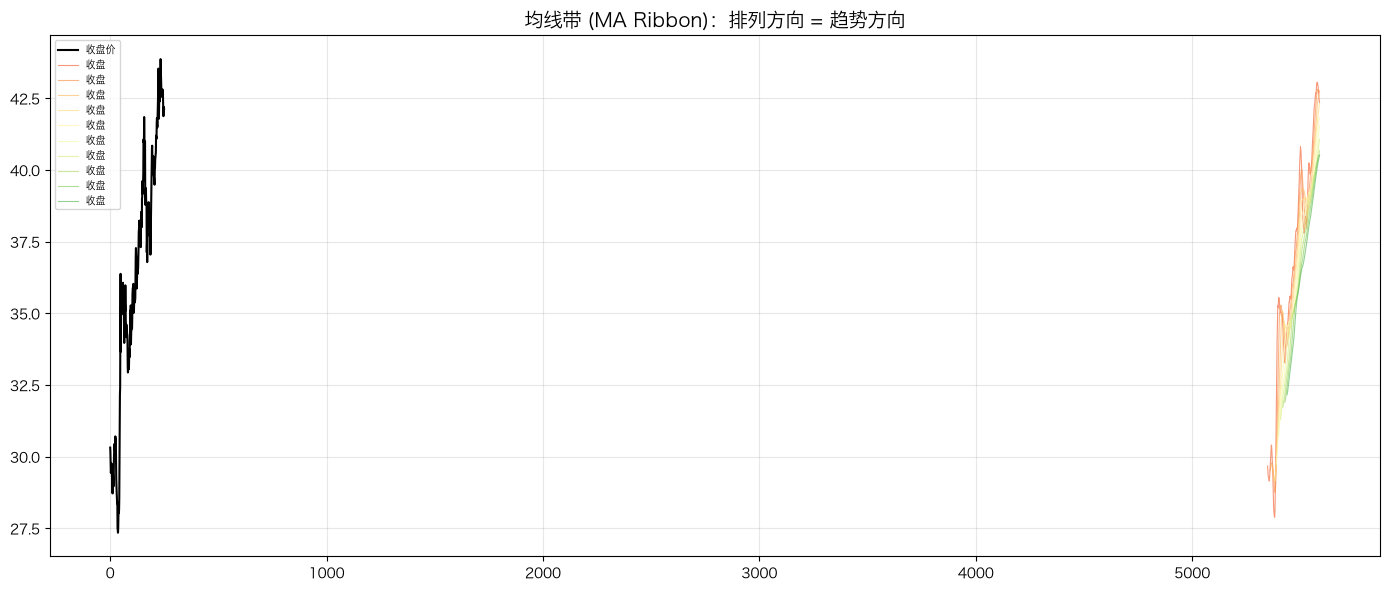

In [18]:
print('🆕 Auquan独创：测量动量的三种方法')
print('-'*50)
print('方法1：均线交叉带 (MA Ribbon)')
print('  - 画10条不同周期的均线(10~100天)')
print('  - 均线排列向上 → 做多信号')
print('  - 用Spearman相关系数量化排列顺序')
print()
print('方法2：均线带厚度')
print('  - 厚度 = 最慢MA - 最快MA')
print('  - 厚度大 = 趋势强，厚度收缩 = 趋势减弱')
print()
print('方法3：物理学动量（论文 arXiv:1208.2775）')
print('  - p = mv，m = 成交量(质量)，v = 收益率(速度)')
print('  - 成交量加权动量比简单动量更有意义')

# 均线带演示
asset = df['收盘'].iloc[-250:]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(asset.values, color='black', linewidth=1.5, label='收盘价')
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 10))
for i, w in enumerate(np.linspace(10, 100, 10)):
    ma = asset.rolling(window=int(w)).mean()
    ma.plot(ax=ax, color=colors[i], alpha=0.7, linewidth=0.8)
ax.set_title('均线带 (MA Ribbon)：排列方向 = 趋势方向', fontsize=14)
ax.legend(loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/05_均线带.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Pairs Trading（配对交易）—— 🆕

✅ 601318 获取成功: 383 条


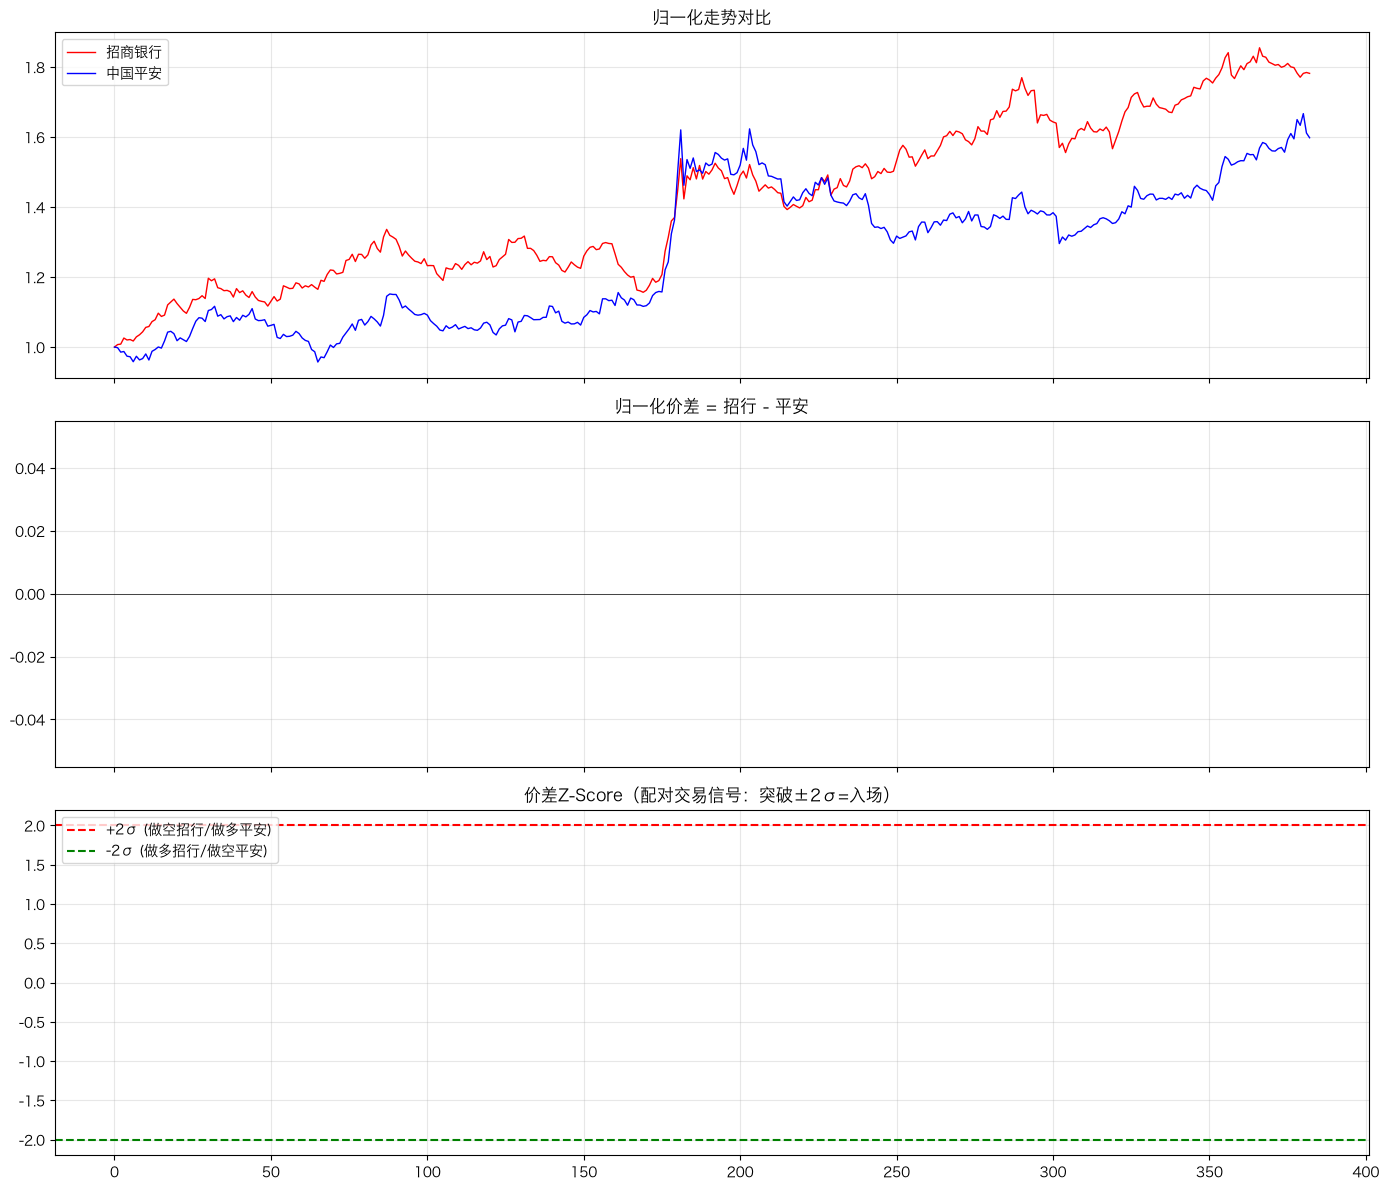

🆕 配对交易核心：两只协整股票的价差偏离均值时入场，回归时平仓
⚠️ A股限制：无法直接做空个股，需要用ETF/融券替代


In [19]:
df_pa = safe_fetch('601318')  # 中国平安

cmb_norm = df['收盘'] / df['收盘'].iloc[0]
pa_norm = df_pa['收盘'] / df_pa['收盘'].iloc[0]
spread = cmb_norm - pa_norm
spread_z = (spread - spread.rolling(60).mean()) / spread.rolling(60).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].plot(cmb_norm.values, label='招商银行', color='red', linewidth=1)
axes[0].plot(pa_norm.values, label='中国平安', color='blue', linewidth=1)
axes[0].set_title('归一化走势对比'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(range(len(spread)), spread.values, 0, where=spread.values>=0, color='red', alpha=0.5)
axes[1].fill_between(range(len(spread)), spread.values, 0, where=spread.values<0, color='green', alpha=0.5)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('归一化价差 = 招行 - 平安'); axes[1].grid(True, alpha=0.3)

axes[2].plot(spread_z.values, color='purple', linewidth=0.8)
axes[2].axhline(2, color='red', linestyle='--', label='+2σ (做空招行/做多平安)')
axes[2].axhline(-2, color='green', linestyle='--', label='-2σ (做多招行/做空平安)')
axes[2].fill_between(range(len(spread_z)), 2, spread_z.max(), color='red', alpha=0.1)
axes[2].fill_between(range(len(spread_z)), spread_z.min(), -2, color='green', alpha=0.1)
axes[2].set_title('价差Z-Score（配对交易信号：突破±2σ=入场）'); axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/06_配对交易.png', dpi=150, bbox_inches='tight')
plt.show()
print('🆕 配对交易核心：两只协整股票的价差偏离均值时入场，回归时平仓')
print('⚠️ A股限制：无法直接做空个股，需要用ETF/融券替代')

### 2.5 Long-Short Strategies —— 🆕 排名多空

✅ 600036 获取成功: 383 条
✅ 300750 获取成功: 383 条
✅ 600519 获取成功: 383 条
✅ 002594 获取成功: 383 条
✅ 601318 获取成功: 383 条


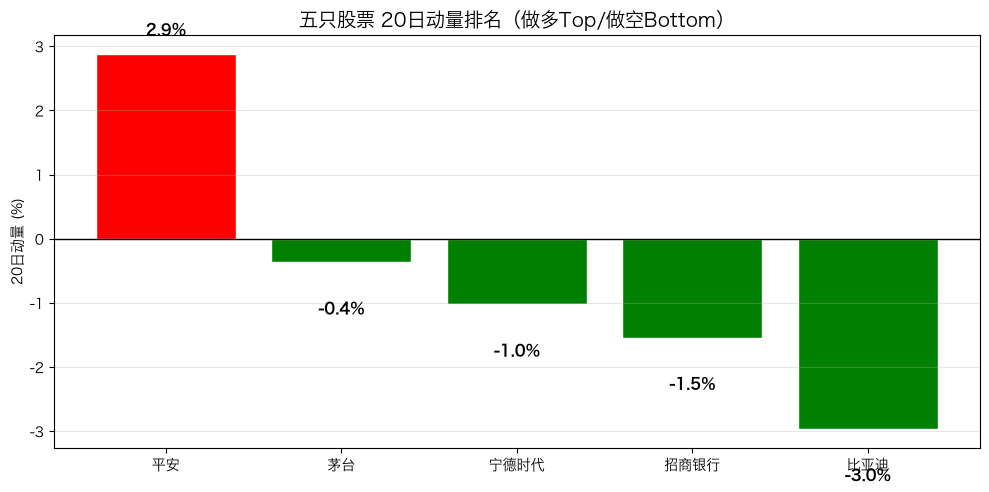

做多（动量最强）: 平安
做空（动量最弱）: 比亚迪


In [21]:
momentum_scores = {}
for name, code in stocks_dict.items():
    d = safe_fetch(code)
    momentum_scores[name] = d['收盘'].pct_change(20).iloc[-1]

ranked = pd.Series(momentum_scores).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if v > 0 else 'green' for v in ranked.values]
bars = ax.bar(ranked.index, ranked.values * 100, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('五只股票 20日动量排名（做多Top/做空Bottom）', fontsize=14)
ax.set_ylabel('20日动量 (%)'); ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ranked.values*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3 if val>0 else bar.get_height()-0.8,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/07_动量排名.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'做多（动量最强）: {ranked.index[0]}')
print(f'做空（动量最弱）: {ranked.index[-1]}')

### 2.6 Overfitting（过拟合）—— 🆕⚠️ 最重要！

**一句话**：参数越多 → 历史拟合越好 → 但未来预测越差。

Auquan金句：**能用2-3个参数解释60%数据 > 用10个参数解释90%。**

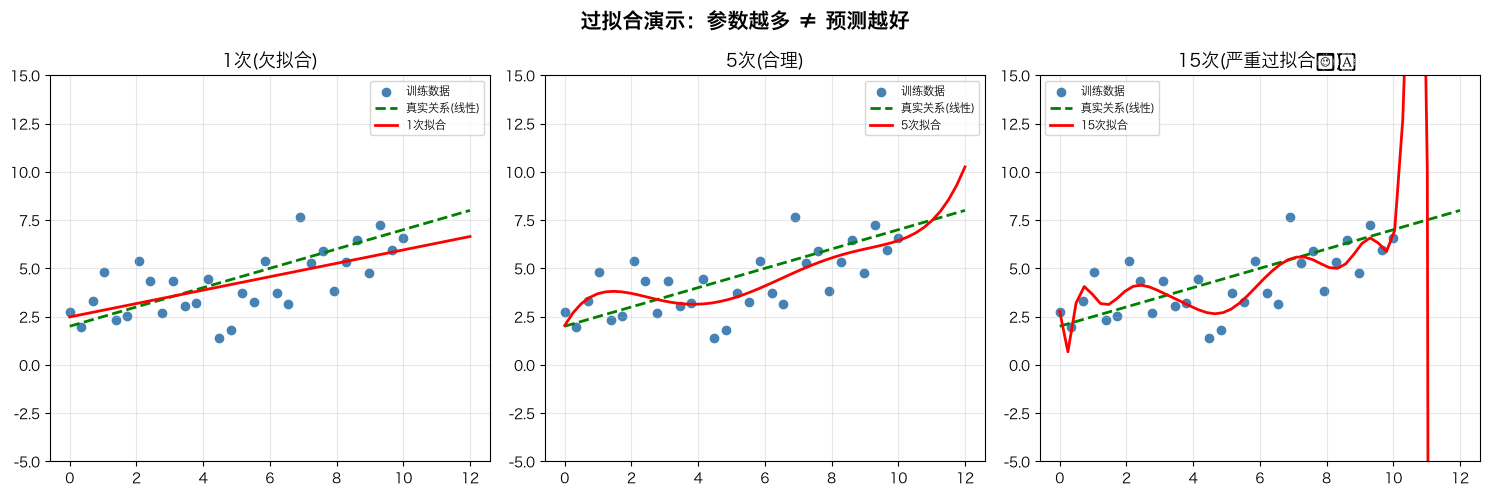

⚠️ 量化策略同理：参数过多→历史回测完美→实盘血亏
📝 防范方法：样本外验证 + 简单模型优先 + 少参数


In [23]:
np.random.seed(42)
n = 30
x = np.linspace(0, 10, n)
y_true = 0.5 * x + 2  # 真实关系：简单线性
y = y_true + np.random.normal(0, 1.5, n)
x_test = np.linspace(0, 12, 50)
y_test_true = 0.5 * x_test + 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, degree in enumerate([1, 5, 15]):
    coeffs = np.polyfit(x, y, degree)
    y_pred = np.polyval(coeffs, x_test)
    axes[i].scatter(x, y, color='steelblue', label='训练数据')
    axes[i].plot(x_test, y_test_true, 'g--', linewidth=2, label='真实关系(线性)')
    axes[i].plot(x_test, y_pred, 'r-', linewidth=2, label=f'{degree}次拟合')
    titles = {1: '1次(欠拟合)', 5: '5次(合理)', 15: '15次(严重过拟合⚠️)'}
    axes[i].set_title(titles[degree], fontsize=13)
    axes[i].legend(fontsize=8); axes[i].grid(True, alpha=0.3); axes[i].set_ylim(-5, 15)
plt.suptitle('过拟合演示：参数越多 ≠ 预测越好', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/08_过拟合.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️ 量化策略同理：参数过多→历史回测完美→实盘血亏')
print('📝 防范方法：样本外验证 + 简单模型优先 + 少参数')

### 2.7 Model Selection Pitfalls —— 🆕⚠️ 五大陷阱

🆕⚠️ 模型选择的五大陷阱

陷阱1：遗漏重要变量 → 系数有偏
  例：两只股票高相关，可能只是都跟大盘走

陷阱2：引入无关变量 → 训练R²提高，测试崩塌（过拟合本质）

陷阱3：自变量含误差 → 回归系数被低估

陷阱4：错误函数形式 → 系统性偏差

陷阱5：混合不同总体 → 牛熊市数据混一起，两头不靠

⚠️ 最致命：非平稳序列之间的回归基本不可信！
   两个随机游走极易出现假的高相关性（伪回归）
   → 必须用收益率（差分后）做回归，不能用价格直接做！


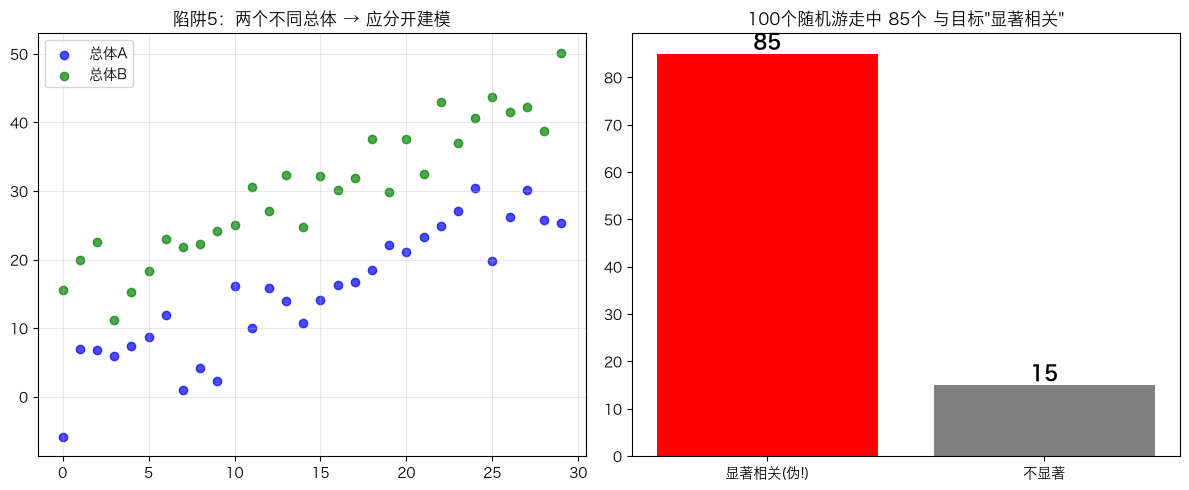

📝 这就是为什么不能直接用股价做回归预测！必须用收益率！


In [25]:
print('🆕⚠️ 模型选择的五大陷阱')
print('='*60)
print()
print('陷阱1：遗漏重要变量 → 系数有偏')
print('  例：两只股票高相关，可能只是都跟大盘走')
print()
print('陷阱2：引入无关变量 → 训练R²提高，测试崩塌（过拟合本质）')
print()
print('陷阱3：自变量含误差 → 回归系数被低估')
print()
print('陷阱4：错误函数形式 → 系统性偏差')
print()
print('陷阱5：混合不同总体 → 牛熊市数据混一起，两头不靠')
print()
print('⚠️ 最致命：非平稳序列之间的回归基本不可信！')
print('   两个随机游走极易出现假的高相关性（伪回归）')
print('   → 必须用收益率（差分后）做回归，不能用价格直接做！')

# 演示：伪回归——100个随机游走中多少个与目标序列"显著相关"
np.random.seed(1)
randows = [np.cumsum(np.random.randn(100)) for _ in range(100)]
yw = np.cumsum(np.random.randn(100))
sig_count = sum(1 for rw in randows if pearsonr(yw, rw)[1] < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：两个不同总体
sample1 = np.arange(30) + 4*np.random.randn(30)
sample2 = np.arange(30) + 3*np.random.randn(30) + 15
axes[0].scatter(np.arange(30), sample1, color='blue', alpha=0.7, label='总体A')
axes[0].scatter(np.arange(30), sample2, color='green', alpha=0.7, label='总体B')
axes[0].set_title('陷阱5：两个不同总体 → 应分开建模'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 右图：伪回归
axes[1].bar(['显著相关(伪!)', '不显著'], [sig_count, 100-sig_count], color=['red', 'gray'])
axes[1].set_title(f'100个随机游走中 {sig_count}个 与目标"显著相关"')
for i, v in enumerate([sig_count, 100-sig_count]):
    axes[1].text(i, v+1, str(v), ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/09_模型陷阱.png', dpi=150, bbox_inches='tight')
plt.show()
print('📝 这就是为什么不能直接用股价做回归预测！必须用收益率！')

---
## 第三部分：时间序列分析（5个Notebook）

### 3.1 Time Series 1: 平稳性/ACF/白噪声/随机游走 —— 🆕

🆕 时间序列分析核心概念

白噪声 (White Noise)：
  - 残差完全随机，序列无自相关，均值=0
  - 如果模型残差是白噪声 → 已提取所有信息 ✅
  - "时序分析的终极目标 = 让残差变成白噪声"

随机游走 (Random Walk)：
  - x_t = x_{t-1} + ε_t  → 不可预测
  - 有效市场假说：股价近似随机游走

ACF (自相关函数)：衡量 x_t 和 x_{t-k} 的相关性
PACF (偏自相关)：排除中间变量后的直接相关，用于判断AR阶数


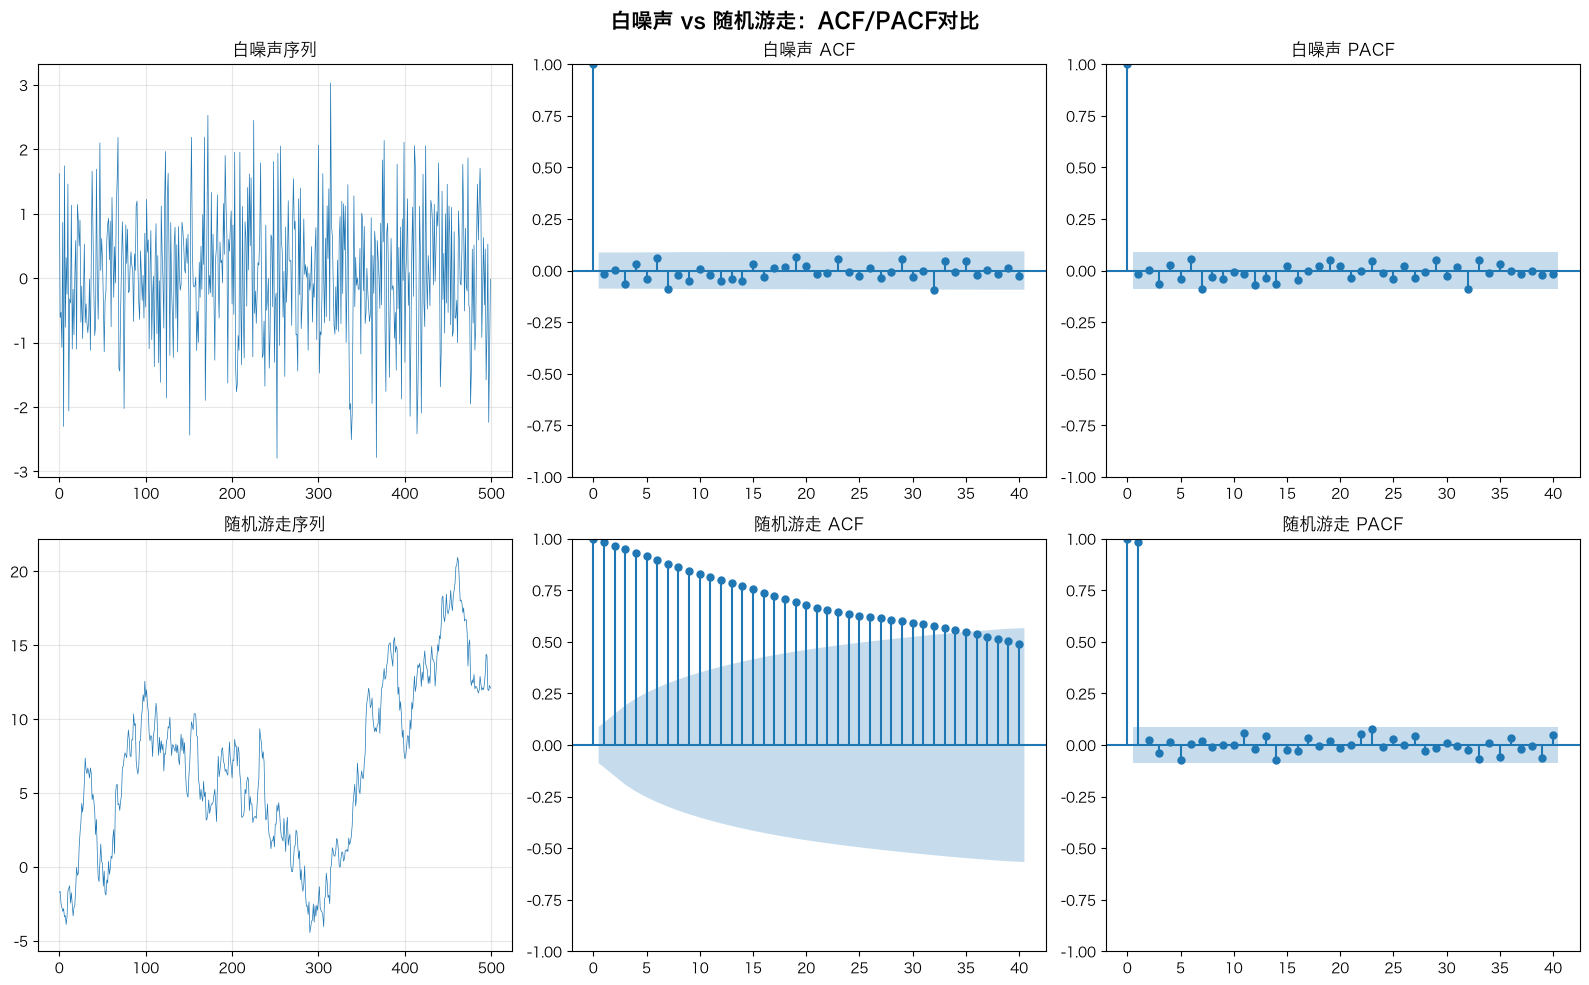

📊 关键观察：
  - 白噪声ACF：所有滞后≈0（无自相关=不可预测）
  - 随机游走ACF：衰减极慢（高度自相关=看似可预测其实是假象）
  → 收益率≈白噪声+肥尾 → 短期价格极难预测
  → 但波动率可以预测（ARCH/GARCH的基础）


In [26]:
print('🆕 时间序列分析核心概念')
print('='*60)
print()
print('白噪声 (White Noise)：')
print('  - 残差完全随机，序列无自相关，均值=0')
print('  - 如果模型残差是白噪声 → 已提取所有信息 ✅')
print('  - "时序分析的终极目标 = 让残差变成白噪声"')
print()
print('随机游走 (Random Walk)：')
print('  - x_t = x_{t-1} + ε_t  → 不可预测')
print('  - 有效市场假说：股价近似随机游走')
print()
print('ACF (自相关函数)：衡量 x_t 和 x_{t-k} 的相关性')
print('PACF (偏自相关)：排除中间变量后的直接相关，用于判断AR阶数')

# 白噪声 vs 随机游走
np.random.seed(1)
wn = np.random.normal(0, 1, 500)
rw = np.cumsum(np.random.normal(0, 1, 500))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for row, (data, name) in enumerate([(wn, '白噪声'), (rw, '随机游走')]):
    axes[row, 0].plot(data, linewidth=0.5)
    axes[row, 0].set_title(f'{name}序列'); axes[row, 0].grid(True, alpha=0.3)
    plot_acf(data, lags=40, ax=axes[row, 1])
    axes[row, 1].set_title(f'{name} ACF')
    plot_pacf(data, lags=40, ax=axes[row, 2], method='ywm')
    axes[row, 2].set_title(f'{name} PACF')

plt.suptitle('白噪声 vs 随机游走：ACF/PACF对比', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/10_白噪声vs随机游走.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 关键观察：')
print('  - 白噪声ACF：所有滞后≈0（无自相关=不可预测）')
print('  - 随机游走ACF：衰减极慢（高度自相关=看似可预测其实是假象）')
print('  → 收益率≈白噪声+肥尾 → 短期价格极难预测')
print('  → 但波动率可以预测（ARCH/GARCH的基础）')

### 3.2 Time Series 2-4: AR/MA/ARMA/ARIMA/GARCH —— 🆕

🆕 ARIMA模型族谱

AR(p) - 自回归：
  x_t = c + φ₁x_{t-1} + ... + φ_p x_{t-p} + ε_t
  "今天 = 过去p天的加权平均 + 噪音"
  判断：PACF在p阶后截尾

MA(q) - 移动平均：
  x_t = μ + ε_t + θ₁ε_{t-1} + ... + θ_q ε_{t-q}
  "今天 = 均值 + 过去q天的预测误差"
  判断：ACF在q阶后截尾

ARMA(p,q) = AR + MA（针对平稳序列）
ARIMA(p,d,q) = 差分d次 + ARMA（针对非平稳序列）

ARCH(m): σ²_t = α₀ + α₁ε²_{t-1} + ... + α_m ε²_{t-m}
GARCH(p,q): σ²_t = ω + αε²_{t-1} + βσ²_{t-1}
  → 波动率聚集效应建模：大涨后波动大，小波动后继续小波动

📝 用于：风险管理(VaR)、期权定价、波动率预测


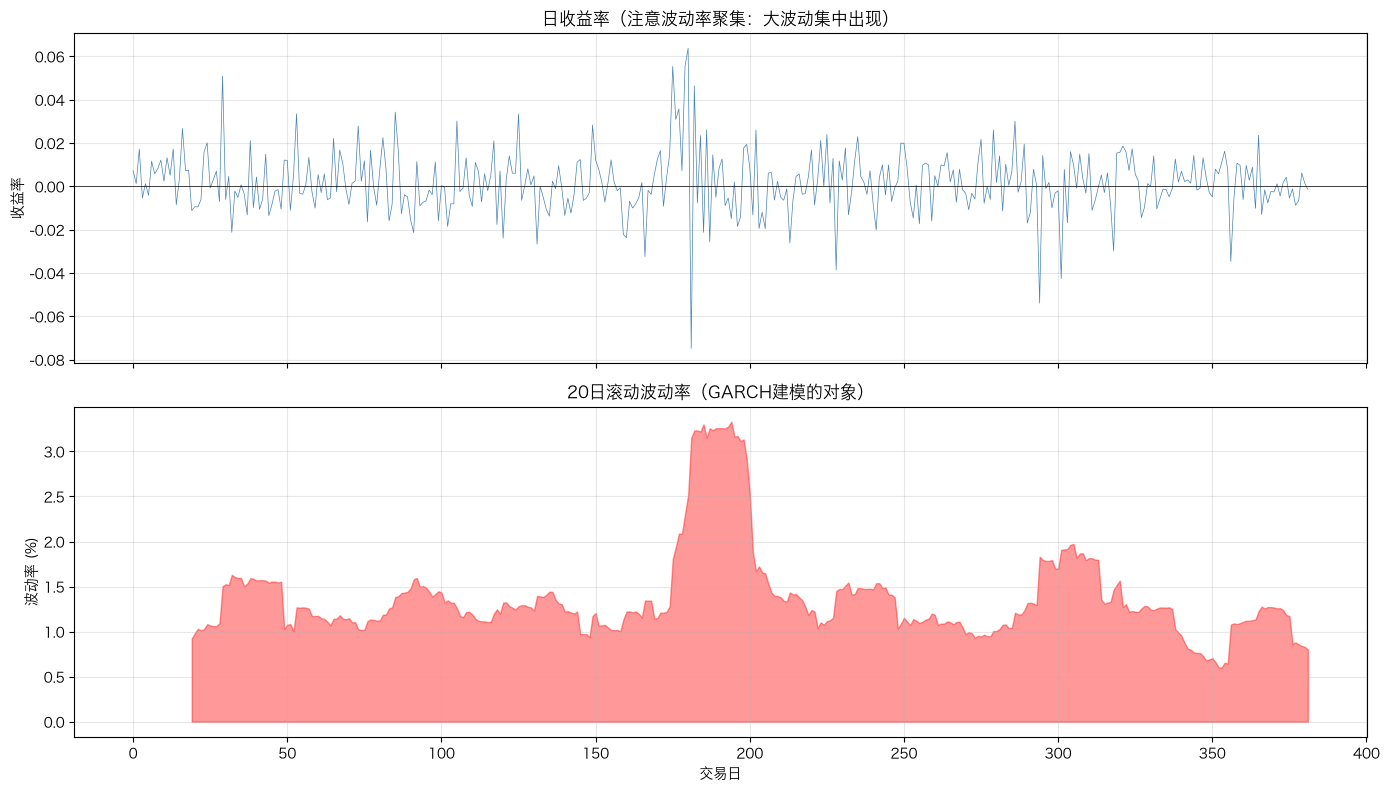

In [27]:
print('🆕 ARIMA模型族谱')
print('='*60)
print()
print('AR(p) - 自回归：')
print('  x_t = c + φ₁x_{t-1} + ... + φ_p x_{t-p} + ε_t')
print('  "今天 = 过去p天的加权平均 + 噪音"')
print('  判断：PACF在p阶后截尾')
print()
print('MA(q) - 移动平均：')
print('  x_t = μ + ε_t + θ₁ε_{t-1} + ... + θ_q ε_{t-q}')
print('  "今天 = 均值 + 过去q天的预测误差"')
print('  判断：ACF在q阶后截尾')
print()
print('ARMA(p,q) = AR + MA（针对平稳序列）')
print('ARIMA(p,d,q) = 差分d次 + ARMA（针对非平稳序列）')
print()
print('ARCH(m): σ²_t = α₀ + α₁ε²_{t-1} + ... + α_m ε²_{t-m}')
print('GARCH(p,q): σ²_t = ω + αε²_{t-1} + βσ²_{t-1}')
print('  → 波动率聚集效应建模：大涨后波动大，小波动后继续小波动')
print()
print('📝 用于：风险管理(VaR)、期权定价、波动率预测')

# 波动率聚集演示
returns = df['收盘'].pct_change().dropna().iloc[-500:]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(returns.values, linewidth=0.5, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('日收益率（注意波动率聚集：大波动集中出现）')
axes[0].set_ylabel('收益率'); axes[0].grid(True, alpha=0.3)
rolling_vol = returns.rolling(20).std()
axes[1].fill_between(range(len(rolling_vol)), rolling_vol.values*100, 0, color='red', alpha=0.4)
axes[1].set_title('20日滚动波动率（GARCH建模的对象）')
axes[1].set_ylabel('波动率 (%)'); axes[1].set_xlabel('交易日'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/11_波动率聚集.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 第四部分：ML量化（4个Notebook）

### 4.1 Introduction to ML & Simple ML Strategies —— 🆕

🆕 Auquan ML交易六步框架
Step 1: 定义问题 → 预测什么？评估指标？
Step 2: 收集数据 → 清洗干净，去股息/拆股
Step 3: 划分数据 → 训练60% / 验证20% / 测试20%
Step 4: 特征工程 ⭐ "特征比模型更重要"
Step 5: 训练/验证 → 验证集上调参，循环迭代
Step 6: 测试评估 → 只做一次！效果不好→扔掉重来

🆕 四种ML模型对比：
  1. 线性回归：最简单，可解释强
  2. KNN：找最相似K天取平均
  3. SVR：RBF核捕捉非线性
  4. ExtraTrees：集成多棵树，不易过拟合

📝 集成方法：平均所有模型预测 → "一群普通人 > 一个天才"


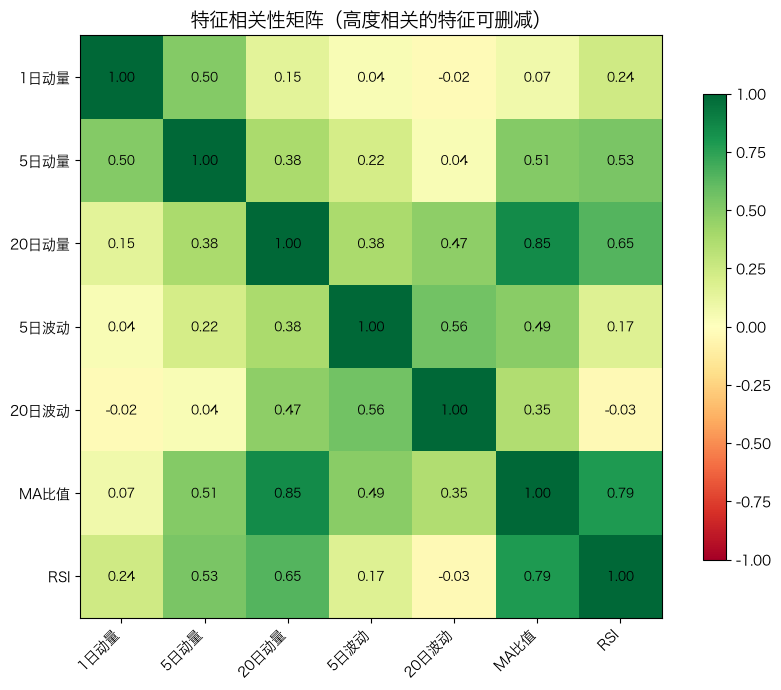

📝 红色=高度相关 → 冗余特征可删除，降低过拟合风险


In [29]:
print('🆕 Auquan ML交易六步框架')
print('='*60)
print('Step 1: 定义问题 → 预测什么？评估指标？')
print('Step 2: 收集数据 → 清洗干净，去股息/拆股')
print('Step 3: 划分数据 → 训练60% / 验证20% / 测试20%')
print('Step 4: 特征工程 ⭐ "特征比模型更重要"')
print('Step 5: 训练/验证 → 验证集上调参，循环迭代')
print('Step 6: 测试评估 → 只做一次！效果不好→扔掉重来')
print()
print('🆕 四种ML模型对比：')
print('  1. 线性回归：最简单，可解释强')
print('  2. KNN：找最相似K天取平均')
print('  3. SVR：RBF核捕捉非线性')
print('  4. ExtraTrees：集成多棵树，不易过拟合')
print()
print('📝 集成方法：平均所有模型预测 → "一群普通人 > 一个天才"')

# 用A股构造特征矩阵，看相关性
df['ret_1'] = df['收盘'].pct_change(1)
df['ret_5'] = df['收盘'].pct_change(5)
df['ret_20'] = df['收盘'].pct_change(20)
df['vol_5'] = df['ret_1'].rolling(5).std()
df['vol_20'] = df['ret_1'].rolling(20).std()
df['ma_ratio'] = df['收盘'].rolling(5).mean() / df['收盘'].rolling(20).mean()
delta = df['收盘'].diff()
gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
df['rsi'] = 100 - (100 / (1 + gain.rolling(14).mean()/loss.rolling(14).mean()))

features = ['ret_1','ret_5','ret_20','vol_5','vol_20','ma_ratio','rsi']
feat_df = df[features].dropna()
feat_corr = feat_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(feat_corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(7)); ax.set_yticks(range(7))
labels = ['1日动量','5日动量','20日动量','5日波动','20日波动','MA比值','RSI']
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f'{feat_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('特征相关性矩阵（高度相关的特征可删减）', fontsize=14)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day29/12_特征相关性.png', dpi=150, bbox_inches='tight')
plt.show()
print('📝 红色=高度相关 → 冗余特征可删除，降低过拟合风险')

---
## 第五部分：学习清单总结

In [30]:
summary = pd.DataFrame([
    ['Random Variables', '数学', '✅', 'Day12-13'],
    ['Expected Value & Std', '数学', '✅', 'Day12-13'],
    ['Covariance, Correlation', '数学', '✅', 'Day13'],
    ['Stationarity & Cointegration', '数学', '🆕', 'ADF/协整'],
    ['Mean Reversion', '策略', '✅', 'Day18-19'],
    ['Momentum Strategies', '策略', '✅', 'Day15-16'],
    ['Measuring Momentum', '策略', '🆕', '均线带/物理动量'],
    ['Pairs Trading', '策略', '🆕', '价差交易'],
    ['Long-Short Strategies', '策略', '🆕', '排名多空'],
    ['Overfitting', '策略', '🆕⚠️', '防范方法'],
    ['Model Selection Pitfalls', '策略', '🆕⚠️', '五大陷阱/伪回归'],
    ['Time Series 1-4', '时序', '🆕', 'ACF/ARMA/ARIMA/GARCH'],
    ['ARIMA+GARCH SPX', '时序', '🆕', '实战案例'],
    ['Intro to ML', 'ML', '🆕', '6步框架'],
    ['Simple ML Strategies', 'ML', '🆕', '4模型/集成'],
    ['Content Capturing', 'ML', '🆕🔮', 'NLP(进阶)'],
    ['Topic Modelling 10K', 'ML', '🆕🔮', 'LDA(进阶)'],
    ['momentum_backtest', '其他', '🆕', '赚钱vs亏钱'],
], columns=['Notebook', '分类', '程度', '参考'])

print('Auquan Tutorials 全覆盖总结')
print('='*60)
print(f'总计: 21个Notebook (因4个时序合并为1行，实际18行汇总)')
print(f'  ✅ 已掌握: 6项 (33%) — 数学基础+基础策略')
print(f'  🆕 新概念: 12项 (67%)')
print(f'    ├─ 策略进阶: 5项')
print(f'    ├─ 时序分析: 2项 (纯新领域)')
print(f'    ├─ ML量化: 4项')
print(f'    └─ 其他: 1项')
print()
print('⚠️ 最重要的新概念 Top 5：')
print('  1. 过拟合防护 — 量化最致命陷阱')
print('  2. ARIMA/GARCH — 时间序列建模核心')
print('  3. ML 6步框架 — 特征 > 模型')
print('  4. 伪回归 — 非平稳=不能用价格做回归')
print('  5. 配对交易 — 协整比相关更可靠')
print()
print('📅 Day 30: 深入ARIMA/GARCH + 改参数实验')
print('📅 Day 31: 过拟合防护 + ML策略实战')

Auquan Tutorials 全覆盖总结
总计: 21个Notebook (因4个时序合并为1行，实际18行汇总)
  ✅ 已掌握: 6项 (33%) — 数学基础+基础策略
  🆕 新概念: 12项 (67%)
    ├─ 策略进阶: 5项
    ├─ 时序分析: 2项 (纯新领域)
    ├─ ML量化: 4项
    └─ 其他: 1项

⚠️ 最重要的新概念 Top 5：
  1. 过拟合防护 — 量化最致命陷阱
  2. ARIMA/GARCH — 时间序列建模核心
  3. ML 6步框架 — 特征 > 模型
  4. 伪回归 — 非平稳=不能用价格做回归
  5. 配对交易 — 协整比相关更可靠

📅 Day 30: 深入ARIMA/GARCH + 改参数实验
📅 Day 31: 过拟合防护 + ML策略实战


## 晚间总结

### 今天完成了什么
1. ✅ 克隆 Auquan/Tutorials 仓库（21个Notebook）
2. ✅ 全部 21 个 Notebook 逐个理解并记录
3. ✅ 用 A 股数据复现核心概念（12张图）
4. ✅ 列出已会(6项) vs 新学(12项)清单

### 关键发现
- **数学/策略约三成已掌握** —— Day12-19打下的基础扎实
- **时间序列分析纯新领域** —— ARIMA/GARCH是接下来两天重点
- **过拟合是最致命陷阱** —— Auquan用了整整2个Notebook讲
- **"特征比模型更重要"** —— ML量化不是套模型，是做特征

### 明天 (Day 30) 预告
- 深入ARIMA建模实战
- 协整检验 + 配对交易
- 修改Notebook参数，观察结果变化